In [1]:
# pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Embedding, Flatten
from tensorflow.keras.models import Sequential
import nltk
import string
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings('ignore')

2025-08-26 23:19:58.700959: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/hillaryosei/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hillaryosei/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/hillaryosei/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
# Load imdb file
imdb = pd.read_csv("imdb_labelled.txt", delimiter='\t', header=None, names=['review', 'rating'])
imdb

,review,rating
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1
...,...,...
743,I just got bored watching Jessice Lange take h...,0
744,"Unfortunately, any virtue in this film's produ...",0
745,"In a word, it is embarrassing.",0
746,Exceptionally bad!,0


In [4]:
# Inspect dataframe
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  748 non-null    object
 1   rating  748 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


rating
1    386
0    362
Name: count, dtype: int64


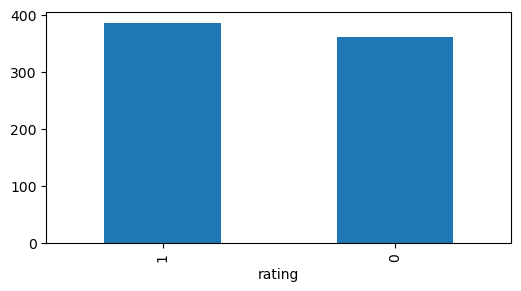

In [5]:
# Inspect distribution of ratings
# 0 = negative, 1 = positive
print(imdb['rating'].value_counts())

plt.figure(figsize=(6,3))
imdb['rating'].value_counts().plot(kind='bar')
plt.show()

In [6]:
# Check presence of unusual characters

chars = (
    imdb["review"].astype(str)
      .str.extractall(r'(.)')[0] # Extract one char per row
      .drop_duplicates()
      .tolist()
)
print(chars)

['A', ' ', 'v', 'e', 'r', 'y', ',', 's', 'l', 'o', 'w', '-', 'm', 'i', 'n', 'g', 'a', 'b', 'u', 't', 'd', 'f', '.', 'N', 'h', 'c', 'k', 'p', '&', 'x', 'V', 'T', 'G', 'I', "'", 'W', 'S', 'L', 'J', 'B', 'F', 'M', 'H', 'C', '"', '\x96', '\t', '1', 'z', '?', 'q', 'Y', '0', 'j', 'P', 'U', 'R', 'E', '3', ';', '/', 'O', '2', '9', ':', '*', 'D', 'Q', 'é', '(', ')', '!', 'K', '$', '7', '5', 'Z', '\x85', '8', '+', '%', '4', 'å', '6', '\x97', 'X']


In [7]:
# Check for number of characters

# Make sure everything is string; keep one lowercased copy for letters
col_raw   = imdb["review"].astype(str)
col_lower = col_raw.str.lower()

# Unique alphanumeric letters
alpha_chars = (
    col_lower
      .str.extractall(r'([a-z])')[0]   # one letter per row
      .drop_duplicates()               # keep unique letters only
      .tolist()
)

# Unique numeric characters
num_chars = (
    col_raw
      .str.extractall(r'([0-9])')[0]
      .drop_duplicates()
      .tolist()
)

# Unique special characters
special_chars = (
    col_raw
      .str.extractall(r'([^A-Za-z0-9\s])')[0]
      .drop_duplicates()
      .tolist()
)

print("Alpha Characters:")
print(alpha_chars)
print("Total of", len(alpha_chars), "unique English letters in this dataset.\n")

print("Numeric Characters:")
print(num_chars)
print("Total of", len(num_chars), "unique numerical characters in this dataset.\n")

print("Special Characters:")
print(special_chars)
print("Total of", len(special_chars), "unique special characters in this dataset.")

Alpha Characters:
['a', 'v', 'e', 'r', 'y', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'b', 'u', 't', 'd', 'f', 'h', 'c', 'k', 'p', 'x', 'j', 'z', 'q']
Total of 26 unique English letters in this dataset.

Numeric Characters:
['1', '0', '3', '2', '9', '7', '5', '8', '4', '6']
Total of 10 unique numerical characters in this dataset.

Special Characters:
[',', '-', '.', '&', "'", '"', '\x96', '?', ';', '/', ':', '*', 'é', '(', ')', '!', '$', '+', '%', 'å', '\x97']
Total of 21 unique special characters in this dataset.


In [8]:
# pip install emoji

In [9]:
# Check for emojis
import emoji

def checkEmoji(text):
    has_emoji = any(emoji.is_emoji(char) for char in text)
    return has_emoji

imdb["emoji"] = imdb['review'].apply(lambda x: checkEmoji(x))

emoji_counts = imdb['emoji'].value_counts()
print(emoji_counts)

emoji
False    748
Name: count, dtype: int64


In [10]:
# Removes unusual characters + converts reviews to all lowercase, tokenizes & lemmatizes reviews, & removes stopwords

# Create an empty list to store cleaned reviews
description_list = []

# Define the list of stopwords, set language to English
stop_words = stopwords.words('english')

# Remove special characters
for description in imdb['review']: 
    description = re.sub("[^a-zA-Z]", " ", description) 
# Convert to lower case
    description = description.lower()
# Perform tokenization
    description = nltk.word_tokenize(description)
# Perform lemmatization
    lemma = nltk.WordNetLemmatizer()
    description = [lemma.lemmatize(word) for word in description]
# Remove stopwords
    description = [word for word in description if not word in stop_words]
    description = " ".join(description)
    description_list.append(description)

In [11]:
# Create new dataframe for description
description_df = pd.DataFrame(description_list, columns=['clean_reviews'])

# Concat rating from the original dataframe to this new dataframe
description_df = pd.concat([description_df, imdb['rating']], axis=1)

description_df.head()

,clean_reviews,rating
0,slow moving aimless movie distressed drifting ...,0
1,sure wa lost flat character audience nearly ha...,0
2,attempting artiness black white clever camera ...,0
3,little music anything speak,0
4,best scene movie wa gerardo trying find song k...,1


In [12]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(description_df['clean_reviews'])
print("Number of unique words:", len(tokenizer.word_index) + 1)

Number of unique words: 2719


In [13]:
# Calculate the minimum, maximum, and median review lengths 
review_length = []
for char_len in description_df['clean_reviews']:
    review_length.append(len(char_len.split(" ")))

review_max = np.max(review_length)
review_min = np.min(review_length)
review_median = np.median(review_length)

print("Max length of sequences is:", review_max)
print("Min length of sequences is:", review_min)
print("Median length of sequences is:", review_median)

# The median review length will be used as the proposed word embedded length here: 
print("Proposed word embedding length:", review_median)

Max length of sequences is: 703
Min length of sequences is: 1
Median length of sequences is: 7.0
Proposed word embedding length: 7.0


In [14]:
# Statistical justification for chosen max sequence length
print("Maximum sequence length:", review_max)

Maximum sequence length: 703


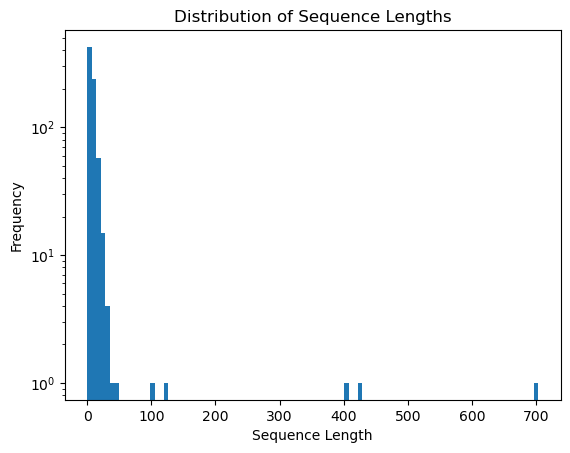

In [15]:
# Calculate sequence lengths
text = description_df["clean_reviews"].astype(str).str.strip()
sequence_lengths = text.str.split().str.len()

# Plot sequence length
plt.hist(sequence_lengths, bins=100)
plt.yscale("log")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sequence Lengths")
plt.show()

In [16]:
# Tokenization of original dataframe for comparison
tokenizer.fit_on_texts(imdb['review'])
word_count = len(tokenizer.word_index) + 1
print("Number of unique words:", word_count)

# Print imdb tokens
imdb['review'].apply(word_tokenize)

Number of unique words: 3342


0      [A, very, ,, very, ,, very, slow-moving, ,, ai...
1      [Not, sure, who, was, more, lost, -, the, flat...
2      [Attempting, artiness, with, black, &, white, ...
3      [Very, little, music, or, anything, to, speak,...
4      [The, best, scene, in, the, movie, was, when, ...
                             ...                        
743    [I, just, got, bored, watching, Jessice, Lange...
744    [Unfortunately, ,, any, virtue, in, this, film...
745            [In, a, word, ,, it, is, embarrassing, .]
746                              [Exceptionally, bad, !]
747    [All, in, all, its, an, insult, to, one, 's, i...
Name: review, Length: 748, dtype: object

In [17]:
# Tokenization of description_df
tokenizer = Tokenizer()
tokenizer.fit_on_texts(description_df['clean_reviews'])
print("Number of unique words:", len(tokenizer.word_index) + 1)

# Print tokens
description_df['clean_reviews'].apply(word_tokenize)

Number of unique words: 2719


0      [slow, moving, aimless, movie, distressed, dri...
1      [sure, wa, lost, flat, character, audience, ne...
2      [attempting, artiness, black, white, clever, c...
3                       [little, music, anything, speak]
4      [best, scene, movie, wa, gerardo, trying, find...
                             ...                        
743    [got, bored, watching, jessice, lange, take, c...
744    [unfortunately, virtue, film, production, work...
745                                 [word, embarrassing]
746                                 [exceptionally, bad]
747      [insult, one, intelligence, huge, waste, money]
Name: clean_reviews, Length: 748, dtype: object

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# (DataCamp, Machine Translation with Keras, n.d.)

# Pad sequences
sequences = tokenizer.texts_to_sequences(description_list)
padded_sequences = pad_sequences(sequences, maxlen=review_max, padding='post')

print(padded_sequences)

[[ 197  304 1040 ...    0    0    0]
 [ 417    3  306 ...    0    0    0]
 [1044 1045  102 ...    0    0    0]
 ...
 [ 143  468    0 ...    0    0    0]
 [2718    5    0 ...    0    0    0]
 [ 398    4  380 ...    0    0    0]]


In [19]:
# Padding

n = random.randint(0, len(description_list))
print('Original Review:')
print('"', description_df.clean_reviews[n], '"')
print('\n')
print('')

print('Review after split, lemmatized, and stop words removed:')
print(description_list[n])
print('\n')
print('')

print('Review tokenized, sequenced, and padded:')
print(padded_sequences[n])

Original Review:
" keep watching "



Review after split, lemmatized, and stop words removed:
keep watching



Review tokenized, sequenced, and padded:
[201  34   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0 

In [20]:
import tensorflow as tf

num_classes = 2  # represents the two categories: positive/negative

model = tf.keras.Sequential([
    tf.keras.layers.Dense(num_classes, activation='sigmoid')
])

print("Number of sentiment categories:", num_classes)

Number of sentiment categories: 2


In [21]:
# Create model 
from keras.models import Sequential
from keras.layers import Embedding, Dense, GRU
from keras import backend
from tensorflow.keras.callbacks import EarlyStopping

activation = 'sigmoid'
loss = 'binary_crossentropy'
optimizer = 'adam' 
num_epochs = 20
embedding_dim = 7

# Define early stopping monitor 
early_stopping_monitor = EarlyStopping(patience=2)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=word_count+1, 
                              output_dim=embedding_dim,
                              input_length=review_max),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1, activation=activation)
])

model.compile(loss=loss,optimizer=optimizer,metrics=['accuracy'])
_ = model(tf.zeros((1, review_max), dtype=tf.int32))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 703, 7)            │        23,401 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (1, 128)               │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 100)               │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 50)                │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 1)                 │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,010 (367.23 KB)

 Trainable params: 94,010 (367.23 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Prep for splitting data

padded_X = pad_sequences(sequences, padding='post', truncating='post', maxlen=review_max)

X = padded_X
y = description_df['rating'].values

In [23]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Check to verify model setting (dense, activation, loss)
print("First 5 y_train rows:\n", np.array(y_train)[:5])
print("Unique values in y_train:", np.unique(np.array(y_train)))

First 5 y_train rows:
 [1 0 0 0 0]
Unique values in y_train: [0 1]


In [25]:
# Get size and shape of testing and training set
print("X_train shape:", np.array(X_train).shape, "and size:", np.array(X_train).size)
print("X_test shape:", np.array(X_test).shape, " and size:", np.array(X_test).size)
print("y_train shape:", np.array(y_train).shape, "and size:", np.array(y_train).size)
print("y_test shape:", np.array(y_test).shape, "and size:", np.array(y_test).size)

X_train shape: (598, 703) and size: 420394
X_test shape: (150, 703)  and size: 105450
y_train shape: (598,) and size: 598
y_test shape: (150,) and size: 150


In [27]:
# Save training and testing data
pd.DataFrame(X_train).to_csv('X_train.csv')
pd.DataFrame(X_test).to_csv('X_test.csv')
pd.DataFrame(y_train).to_csv('y_train.csv')
pd.DataFrame(y_test).to_csv('y_test.csv')

In [28]:
# Saved cleaned df
pd.DataFrame(description_df).to_csv("d213-task2.csv")

In [29]:
# Train model
result = model.fit(X_train, y_train, epochs=20, batch_size=50, validation_split=0.3, 
                    callbacks=[early_stopping_monitor], verbose=True)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.4545 - loss: 0.6934 - val_accuracy: 0.5444 - val_loss: 0.6928
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5120 - loss: 0.6933 - val_accuracy: 0.5444 - val_loss: 0.6922
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5120 - loss: 0.6930 - val_accuracy: 0.5444 - val_loss: 0.6924
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5120 - loss: 0.6930 - val_accuracy: 0.5444 - val_loss: 0.6919
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5120 - loss: 0.6930 - val_accuracy: 0.5444 - val_loss: 0.6919
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5120 - loss: 0.6929 - val_accuracy: 0.5444 - val_loss: 0.6917
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5120 - loss: 0.6929 - val_accuracy: 0.5444 - val_loss: 0.6918
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5120 - loss: 0.6930 - val_accuracy: 0.5444 - val_loss: 0.6920


In [30]:
# Get model accuracy scores
testing_score = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', {testing_score[1]})

training_score = model.evaluate(X_train, y_train, verbose=0)
print('Train accuracy:', {training_score[1]})

Test accuracy: {0.4933333396911621}
Train accuracy: {0.52173912525177}


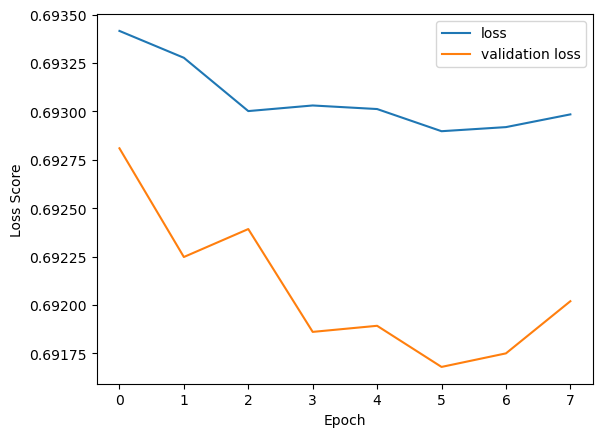

In [31]:
# Visualize loss
plt.plot(result.history['loss'], label='loss')
plt.plot(result.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Score')
plt.legend()
plt.show()

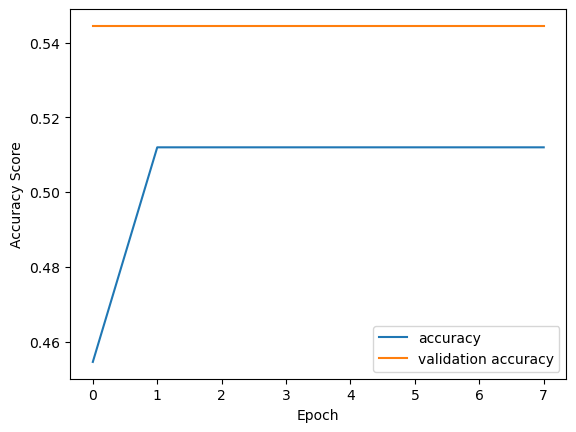

In [32]:
# Visualize accuracy
plt.plot(result.history['accuracy'], label='accuracy')
plt.plot(result.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [33]:
# Save trained network
model.save('d213-model.h5')